In [1]:
import torch
import numpy as np

In [2]:
latent_sc = np.load('latent_sc_st/latent_sc.npy')
latent_st = np.load('latent_sc_st/latent_st.npy')

In [3]:
latent_sc = torch.tensor(latent_sc, device='cuda:0')
latent_st = torch.tensor(latent_st, device='cuda:0')

**************************************************
S: torch.Size([1000, 100, 1])
G: torch.Size([1000, 100, 1])


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:01<00:00, 414.95it/s]


Epoch 500: Loss -1.856940507888794
[[ 8.901131    4.2352076  -1.4263787  ... -1.1876608  -0.8494201
   7.3300114 ]
 [ 5.868645    8.399107   -1.3355883  ...  1.1996734  -0.8789202
   0.80907345]
 [ 0.8508358  -2.055949    8.667938   ...  6.806515   -3.8352106
  -2.1564598 ]
 ...
 [-1.4915513   0.21399136  5.5770035  ...  8.258226    1.8316784
  -1.0822341 ]
 [-2.9122183  -1.8440298  -1.3299912  ... -1.2468203   8.789462
   1.5058326 ]
 [-2.6749368  -0.66870743 -0.6515812  ... -3.1610785  -0.0546134
   9.014512  ]]


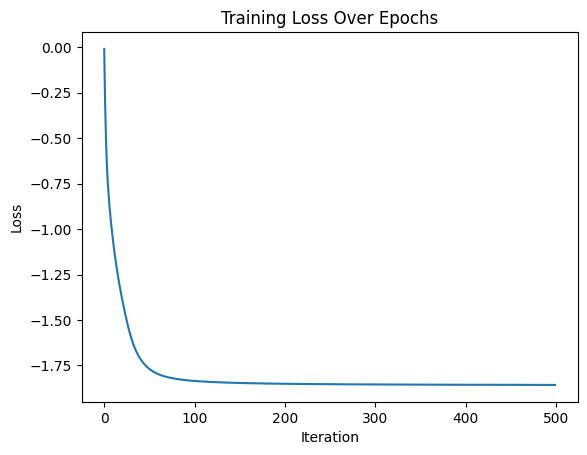

In [5]:
import sim_tangram.train_tangram as tg_cca
# tangram
cca_tg_sim, _ = tg_cca.read_csv_and_run_tangram(
    [latent_sc],
    [latent_st],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

**************************************************
S: torch.Size([1000, 100, 1])
G: torch.Size([1000, 100, 1])


 50%|█████     | 250/500 [00:00<00:00, 2498.23it/s]

100%|██████████| 500/500 [00:00<00:00, 2513.59it/s]


Epoch 500: Loss -0.896961510181427
[[ 9.923166    3.8557618  -1.9704285  ... -1.1325042  -0.89398175
   4.70794   ]
 [ 6.715289    8.914488   -1.5619146  ...  1.7807637  -1.7112514
   0.31374806]
 [ 1.0168608  -2.4051073   9.626243   ...  4.3244653  -3.3800092
  -2.1939266 ]
 ...
 [-1.465258   -0.12295087  6.5093327  ...  9.577224    2.2886002
  -0.7826938 ]
 [-2.949076   -2.3743608  -1.9800143  ... -3.1900845   9.193207
   1.1077313 ]
 [-2.6596596  -0.57249045 -0.60896474 ... -2.7279792  -0.3545825
   9.887196  ]]


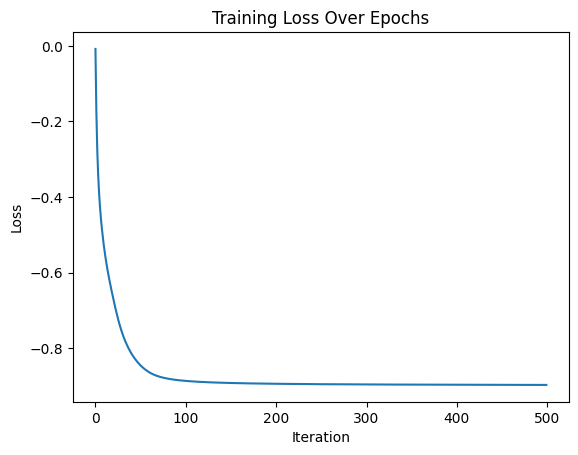

In [6]:
# 用cosine_similarity驱动的tangram进行计算

import cos_tg.train_tangram as tg_cos

# tangram
cos_tg_sim, _ = tg_cos.read_csv_and_run_tangram(
    [latent_sc],
    [latent_st],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=0,
)

In [7]:
# 计算cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc.cpu().numpy(), latent_st.cpu().numpy())
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验cosine_similarity驱动的tangram
cos_tg_mapping = cos_tg_sim.argmax(axis=1)
for i in range(len(cos_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)

# 检验CCA驱动的tangram
cca_tg_mapping = cca_tg_sim.argmax(axis=1)
for i in range(len(cca_tg_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cca_tg_mapping[i]:4d}", end="\t")
print()
print('*'*50)



 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	
**************************************************

 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:  495	28:   28	29:   29	
**************************************************

 0:  381	 1:   

In [8]:
# 计算acc
sample_size = latent_sc.shape[0]
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
tangram_acc = np.sum(cca_tg_mapping == gt) / sample_size
cos_tg_acc = np.sum(cos_tg_mapping == gt) / sample_size

print("cos accuracy:", cos_acc)
print("tangram accuracy:", tangram_acc)
print("cos_tg accuracy:", cos_tg_acc)

cos accuracy: 1.0
tangram accuracy: 0.877
cos_tg accuracy: 0.908
org_cca_tg accuracy: 0.283


: 